# [Deepmath] 10.1. Reconnaissance de chiffres - tensorflow - MNIST

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = "True"

In [2]:
import numpy as np
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense

### Partie A - Les données

In [3]:
from keras.datasets import mnist
from keras.utils import to_categorical

#### Téléchargement des données

In [4]:
(X_train_data, Y_train_data), (X_test_data, Y_test_data) = mnist.load_data()
N = X_train_data.shape[0]  # N = 60 000 données

In [5]:
X_train_data[0].shape

(28, 28)

#### Données d'apprentissage X

In [6]:
X_train = np.reshape(X_train_data,(N,784))  # vecteur image
X_train = X_train/255  # normalisation

#### Données d'apprentissage Y

In [7]:
Y_train = to_categorical(Y_train_data, num_classes=10) # vers une liste de taille 10

In [8]:
print("Y_train_data[0] =",Y_train_data[0])
print("Y_train[0] =", Y_train[0])

Y_train_data[0] = 5
Y_train[0] = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


#### Données de test

In [9]:
X_test = np.reshape(X_test_data,(X_test_data.shape[0],784))
X_test = X_test/255
Y_test = to_categorical(Y_test_data, num_classes=10)

### Partie B - Le réseau de neurones

In [10]:
p = 8
modele = Sequential()

# Première couche : p neurones (entrée de dimension 784 = 28x28)
modele.add(Dense(p, input_dim=784, activation='sigmoid'))

# Deuxième couche : p neurones
modele.add(Dense(p, activation='sigmoid'))

# Couche de sortie : 1O neurones (un par chiffre)
modele.add(Dense(10, activation='softmax'))

# Choix de la méthode de descente de gradient
modele.compile(loss='categorical_crossentropy', 
              optimizer='sgd',  
              metrics=['accuracy'])

print(modele.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 6280      
                                                                 
 dense_1 (Dense)             (None, 8)                 72        
                                                                 
 dense_2 (Dense)             (None, 10)                90        
                                                                 
Total params: 6,442
Trainable params: 6,442
Non-trainable params: 0
_________________________________________________________________
None


### Partie C - Calcul des poids par descente de gradient

In [11]:
modele.fit(X_train, Y_train, batch_size=32, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 7s 3ms/step - loss: 2.2742 - accuracy: 0.2131
Epoch 2/5
1875/1875 [==============================] - 44s 24ms/step - loss: 2.1532 - accuracy: 0.3089
Epoch 3/5
1875/1875 [==============================] - 11s 6ms/step - loss: 1.9757 - accuracy: 0.3401
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 1.8074 - accuracy: 0.4160
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 1.6362 - accuracy: 0.4906


### Partie D - Résultats

In [12]:
resultat = modele.evaluate(X_test, Y_test)
print('Valeur de la fonction erreur sur les données de test (loss):', resultat[0])
print('Précision sur les données de test (accuracy):', resultat[1])

313/313 [==============================] - 1s 2ms/step - loss: 1.5416 - accuracy: 0.5386
Valeur de la fonction erreur sur les données de test (loss): 1.541637897491455
Précision sur les données de test (accuracy): 0.5386000275611877


### Partie E - Résultats un à un

In [13]:
import matplotlib.pyplot as plt

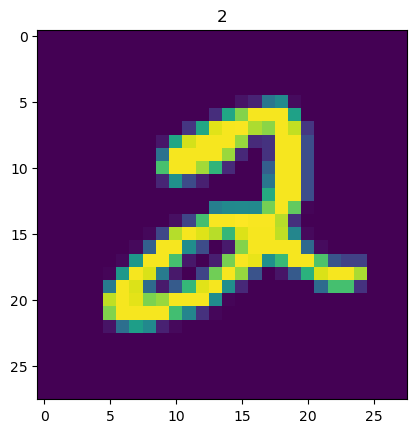

In [14]:
plt.imshow(X_train_data[5])
plt.title(f"{Y_train_data[5]}")
plt.show()